# Phase 2: Market Segmentation via Clustering

In this notebook, you will:
1. Apply K-Means clustering to segment properties into market tiers
2. Use Hierarchical clustering and create dendrograms
3. Implement DBSCAN for density-based property grouping
4. Apply PCA for dimensionality reduction and visualization
5. Determine optimal clusters using Elbow method and Silhouette score
6. Interpret and visualize market segments

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.insert(0, '..')
from src.data_loader import load_housing_data, preprocess_features
from src.clustering import *

## 1. Data Preparation

In [2]:
df = load_housing_data()
X_scaled, y, feature_names, scaler = preprocess_features(df)
print(f"Features shape: {X_scaled.shape}")
print(f"Feature names: {feature_names}")

Features shape: (20640, 8)
Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


## 2. K-Means Clustering

### Finding Optimal K

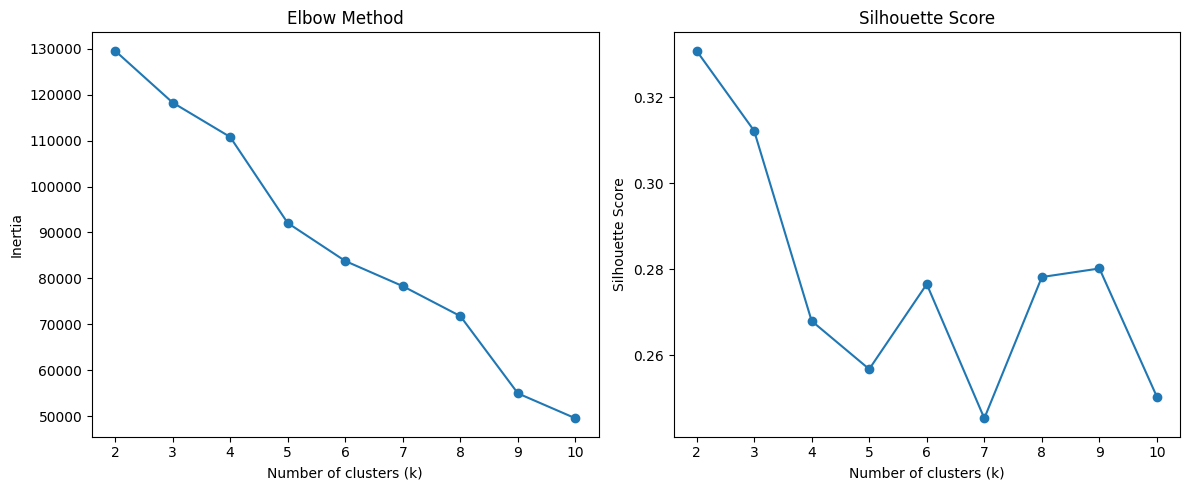

Optimal number of clusters: 4


In [3]:
# TODO: Use find_optimal_k() and plot:
# - Elbow curve (inertia vs k)
# - Silhouette score vs k
k_range = range(2, 11)
inertia_values = []
silhouette_scores = []
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_range, inertia_values, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='o')
plt.title('Silhouette Score')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.tight_layout()
plt.show()
optimal_k = 4  # Based on the plots
print(f"Optimal number of clusters: {optimal_k}")


In [4]:
# TODO: Perform K-Means with optimal k using perform_kmeans()
# Analyze cluster characteristics
kmeans = perform_kmeans(X_scaled, optimal_k)
df['Cluster'] = kmeans['labels']
cluster_summary = df.groupby('Cluster').mean()
print(cluster_summary)

           MedInc   HouseAge  AveRooms  AveBedrms   Population  AveOccup  \
Cluster                                                                    
0        3.205544  32.289872  4.694936   1.060777  1337.987382  3.081513   
1        4.002351  18.480068  5.761423   1.099407  1561.991306  2.863896   
2        3.447624  41.154297  5.159700   1.062396   965.640398  2.712038   
3        6.019419  18.261697  7.283578   1.233083  2027.117280  3.783599   

          Latitude   Longitude  MedHouseVal  
Cluster                                      
0        33.968151 -118.045363     1.917150  
1        37.937935 -121.528959     1.887901  
2        37.919926 -121.937465     2.034411  
3        34.006385 -117.974507     2.791518  


## 3. Hierarchical Clustering

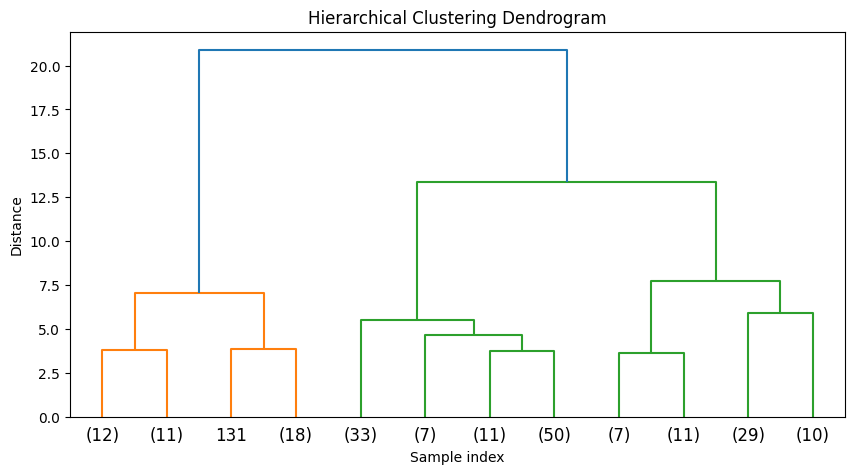

In [5]:
# TODO: Compute linkage matrix and plot dendrogram
# Use a subset for visualization (e.g., first 200 samples)
subset_X = X_scaled[:200]
Z = compute_linkage_matrix(subset_X, method='ward')
plt.figure(figsize=(10, 5))
dendrogram(Z, truncate_mode='lastp', p=12)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.show()

In [18]:
# TODO: Perform hierarchical clustering
# Compare with K-Means results
from scipy.cluster.hierarchy import fcluster

hierarchical_labels = fcluster(Z, t=optimal_k, criterion='maxclust')

# If df_sample was used to build Z, assign via index alignment
df['Hierarchical_Cluster'] = None  # initialize
df.loc[df_sample.index, 'Hierarchical_Cluster'] = hierarchical_labels

hierarchical_summary = df.groupby('Hierarchical_Cluster').mean(numeric_only=True)
print(hierarchical_summary)

                        MedInc   HouseAge  AveRooms  AveBedrms   Population  \
Hierarchical_Cluster                                                          
1                     3.764983  30.428571  5.238001   1.069458  1696.214286   
2                     3.797531  28.811881  5.213560   1.047140  1494.168317   
3                     3.046067  25.555556  4.831445   1.031453  1464.000000   
4                     4.162126  32.435897  5.253971   1.086386  1151.230769   

                      AveOccup   Latitude   Longitude  MedHouseVal   Cluster  
Hierarchical_Cluster                                                          
1                     2.904070  35.401429 -119.490476     2.126167  1.119048  
2                     3.132313  35.361287 -119.285149     2.037436  1.099010  
3                     2.704993  36.006111 -119.677222     1.449833  0.833333  
4                     2.833676  35.489231 -119.570256     2.234179  1.000000  


## 4. DBSCAN Clustering

In [7]:
# TODO: Tune DBSCAN parameters using tune_dbscan()
# Find best eps and min_samples

In [8]:
# TODO: Run DBSCAN with best parameters
# Analyze noise points and clusters

## 5. PCA & Visualization

In [9]:
# TODO: Perform PCA and plot explained variance
# Find optimal number of components for 95% variance

In [10]:
# TODO: Use cluster_with_pca() for 2D visualization
# Create scatter plot colored by cluster labels

## 6. Cluster Interpretation

TODO: For each cluster, analyze:
- Average feature values
- Price distribution
- Geographic distribution
- What "market tier" does each cluster represent?

In [11]:
# TODO: Create cluster profile analysis

## Summary

TODO: Write a summary:
- Which clustering algorithm worked best for this data?
- How many natural market segments exist?
- What characterizes each segment?
- How did PCA help with visualization?